In [1]:
import sys
sys.path.append('../')

from BPMQ import BPMQscan, fmlat
from BPMQ.construct_machineIO import construct_machineIO
import numpy as np

import torch
import time
torch.set_num_threads(2)

In [2]:
machineIO = construct_machineIO()
machineIO._test = True
machineIO._check_chopper_blocking = False
machineIO._fetch_data_time_span = 1
machineIO._ensure_set_timewait_after_ramp = 0.25
machineIO._fetch_data_resample_rate = 0.2

E_MeVu = 130
Mass_number = 18
Charge_number = 8

# preprare BPMQ scan

In [3]:
# Example usage (assuming you have the helper functions defined as before):
filename = "lattice.txt"  # Replace with your lattice file
# from_elem = None #"BDS_BTS:QV_D5501"
from_elem = None #"BDS_BTS:QV_D5501"
to_elem = "BDS_BTS:PM_D5567"
lattice_dicts = fmlat.combine_lattice_elements_quads_only(filename, from_element=from_elem, to_element=to_elem)
for elem_dic in lattice_dicts:
    elem_dic['name'] = fmlat.fmname2mpname(elem_dic['name'])
#, line_name = "cell")
# qnames = ["BDS_BTS:PSQ_D5501", "BDS_BTS:PSQ_D5509", "BDS_BTS:PSQ_D5552", "BDS_BTS:PSQ_D5559"]
qnames = [elem['name'] for elem in lattice_dicts if elem['type']=='quadrupole']
qnames = qnames[:2]
print(qnames)

BPM_names = [elem['name'] for elem in lattice_dicts if 'BPM' in elem['name']][1:]
print(BPM_names)

PM_names = [elem['name'] for elem in lattice_dicts if ':PM_' in elem['name']]
print(PM_names)

if from_elem is None:
    train_BPMQtol = [2]*(len(BPM_names)-2) + [1,1]
else:
    train_BPMQtol = None

['LS3_BTS:PSQ_D4713', 'LS3_BTS:PSQ_D4718']
['LS3_BTS:BPM_D4753', 'LS3_BTS:BPM_D4769', 'LS3_BTS:BPM_D4843', 'LS3_BTS:BPM_D4886', 'LS3_BTS:BPM_D4968', 'LS3_BTS:BPM_D5010', 'LS3_BTS:BPM_D5092', 'LS3_BTS:BPM_D5134', 'LS3_BTS:BPM_D5216', 'LS3_BTS:BPM_D5259', 'LS3_BTS:BPM_D5340', 'LS3_BTS:BPM_D5381', 'LS3_BTS:BPM_D5430', 'LS3_BTS:BPM_D5445', 'BDS_BTS:BPM_D5499', 'BDS_BTS:BPM_D5513', 'BDS_BTS:BPM_D5565']
['BDS_BTS:PM_D5567']


In [4]:
args = (E_MeVu, Mass_number, Charge_number)
kwargs = {
    "quads_to_scan": qnames,
    "quads_max_curr": [140]*len(qnames),
    "quads_min_curr": [ 10]*len(qnames),
    "BPM_names": BPM_names,
    "lattice_dicts" : lattice_dicts,
    "xnemit_target": None,
    "ynemit_target": None,
    "bootstrap":True,
    "machineIO": None,
    "plot_history":True, 
    "plot_ellipse":True,
    "fit_err":False,
    "sample_model_err":True,
    "virtual_beamQerr":1.0,
    "virtual_beamQmodelerr":1.0,
    "BPMQ_model_type":"TIS161_GP",
    "train_BPMQtol":train_BPMQtol
}

# Run for various virtual Qerrs

after init, number of training data is 4
 ======== cs_reconstruct ========


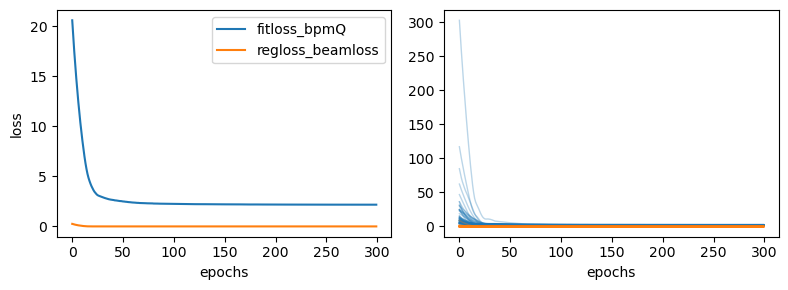

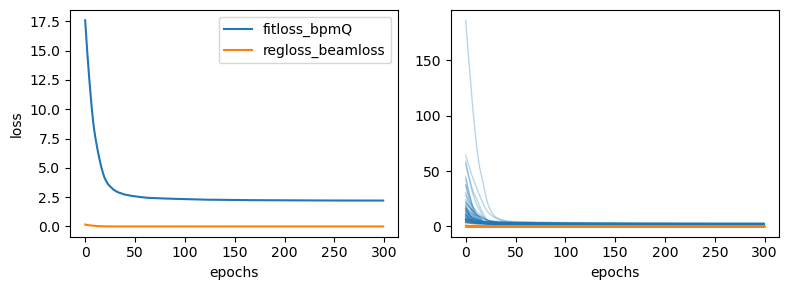

15.210488321987214


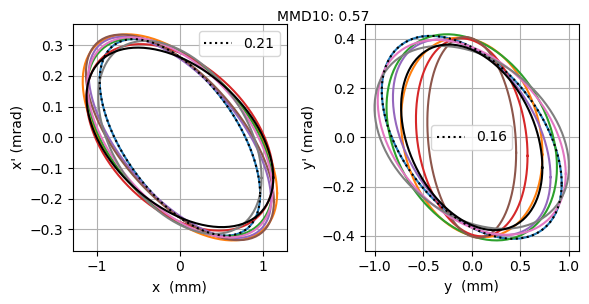

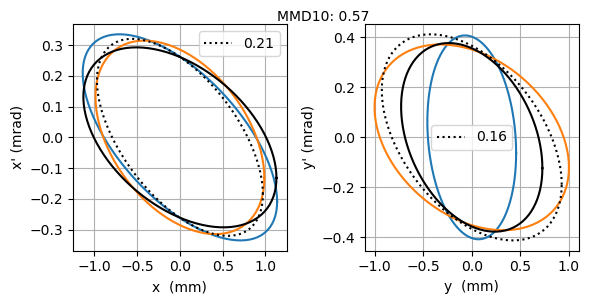

In [5]:
start_time = time.monotonic()
bpmQscan = BPMQscan(*args, **kwargs)
bpmQscan.initialize(n_init=4)
print(time.monotonic()-start_time)

In [6]:
def measure_rms(bpmQscan,lB2):
    env_model = bpmQscan.quads_evaluator.env_model
    env_model.reconfigure_quadrupole_strengths(lB2)
    xcov, ycov = env_model.simulate_beam_covars(env_model.xcovs,env_model.ycovs,i_monitors=env_model.i_pms)
    xrms, yrms = xcov[0,0,0,0]**0.5*1e3, ycov[0,0,0,0]**0.5*1e3
    return xrms, yrms

 ======== query_candidate_quad_set_maximizing_PM_var ========
Early stopping at iteration 137 due to loss stabilization.


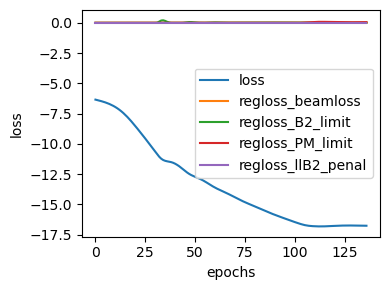

Early stopping at iteration 104 due to loss stabilization.


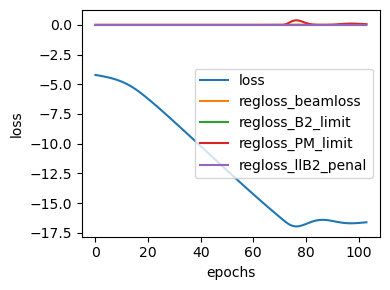

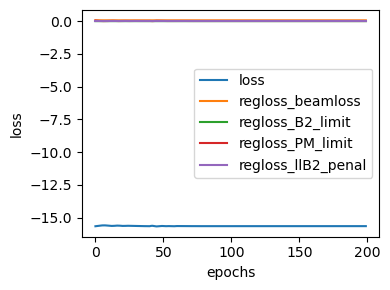

 ======== cs_reconstruct ========


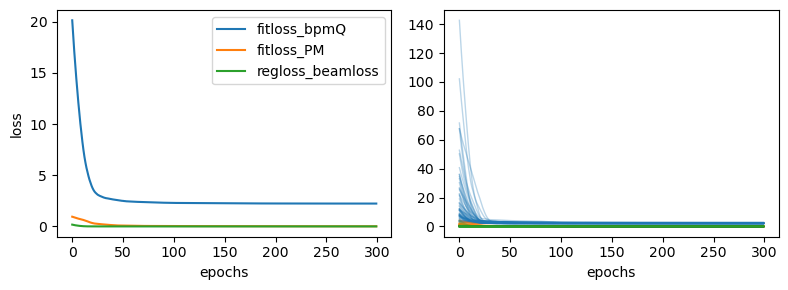

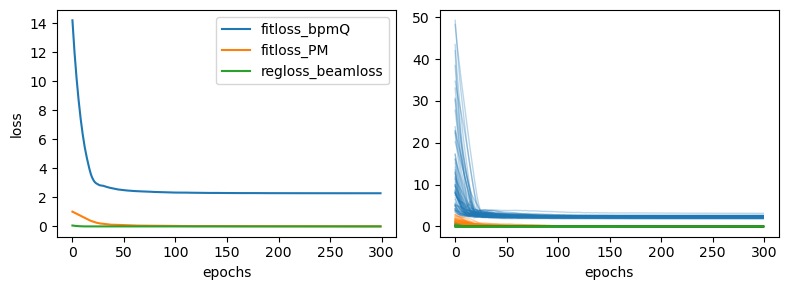

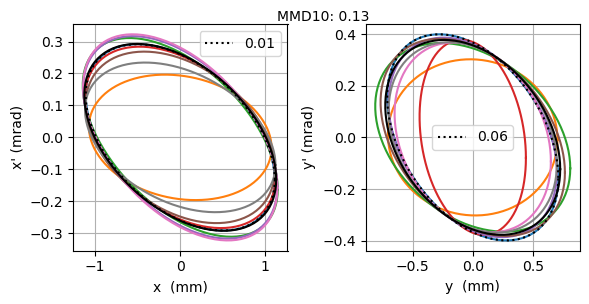

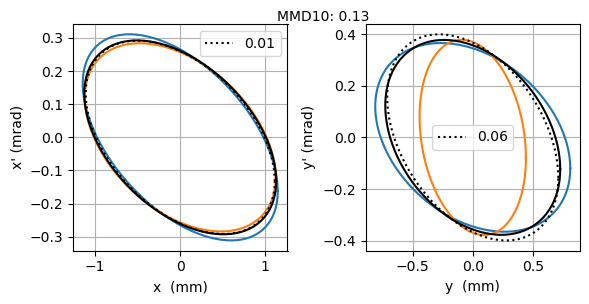

In [7]:
candidate_lB2, ensemble_std_of_PM = bpmQscan.query_candidate_for_PMscan()
xrms, yrms = measure_rms(bpmQscan,candidate_lB2)
bpmQscan.concat_PM_train_data(lB2=candidate_lB2, lxrms=[xrms],lyrms=[yrms])
bpmQscan.train_model()

 ======== query_candidate_quad_set_maximizing_PM_var ========


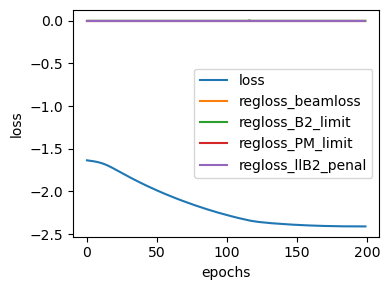

 ======== cs_reconstruct ========


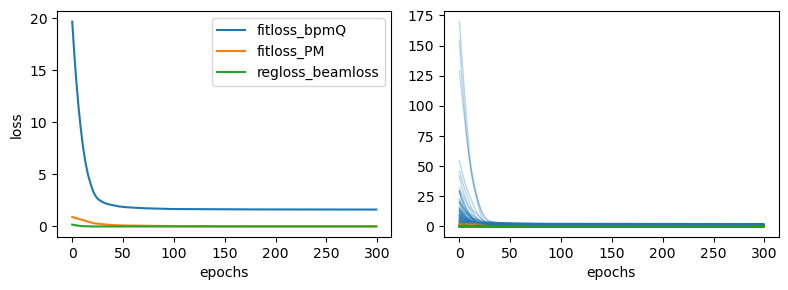

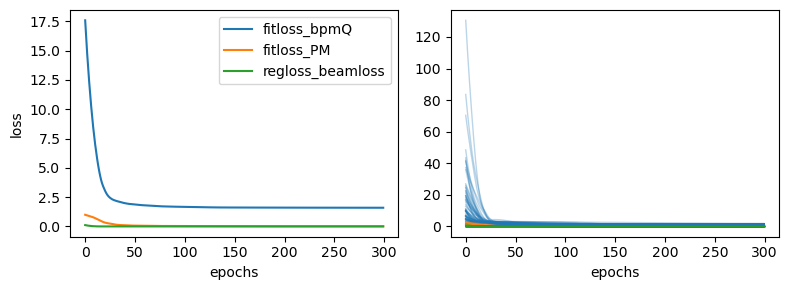

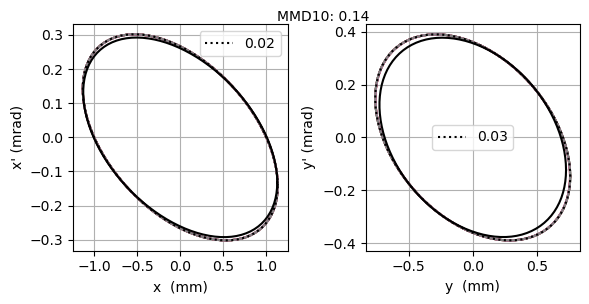

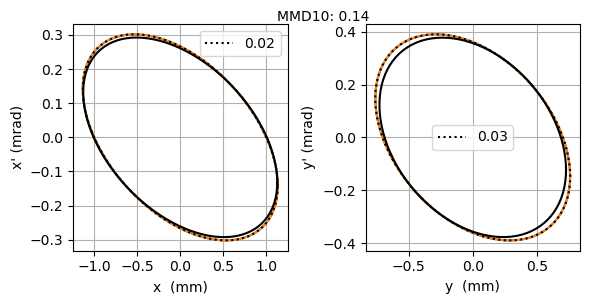

In [8]:
candidate_lB2, ensemble_std_of_PM = bpmQscan.query_candidate_for_PMscan()
xrms, yrms = measure_rms(bpmQscan,candidate_lB2)
bpmQscan.concat_PM_train_data(lB2=candidate_lB2, lxrms=[xrms],lyrms=[yrms])
bpmQscan.train_model(sample_model_err=False,bootstrap=False)

In [9]:
bpmQscan.lB2_to_lICSETs(candidate_lB2)

[10.035897048992167, 68.36765379750929]

In [10]:
candidate_lB2

tensor([-1.1901,  8.1074])